# Data Visualization & Experiment Results

This notebook contains:
1. **CIFAR-100 Partitioning Visualization**: Shows how data is distributed across clients (IID vs non-IID)
2. **Multi-Run Experiment Plots**: Extracts and compares metrics from Weights & Biases runs

---

## Part 1: CIFAR-100 Partitioning Visualization

Visualize how the Flower framework partitions the CIFAR-100 dataset across clients using different partitioning strategies (IID vs Pathological/non-IID).

In [1]:
import os

# Create report/images directory if it doesn't exist
os.makedirs("../report/images", exist_ok=True)

/Users/adrientrahan/Documents/ecole/AML/project/FL-task-arithmetic/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


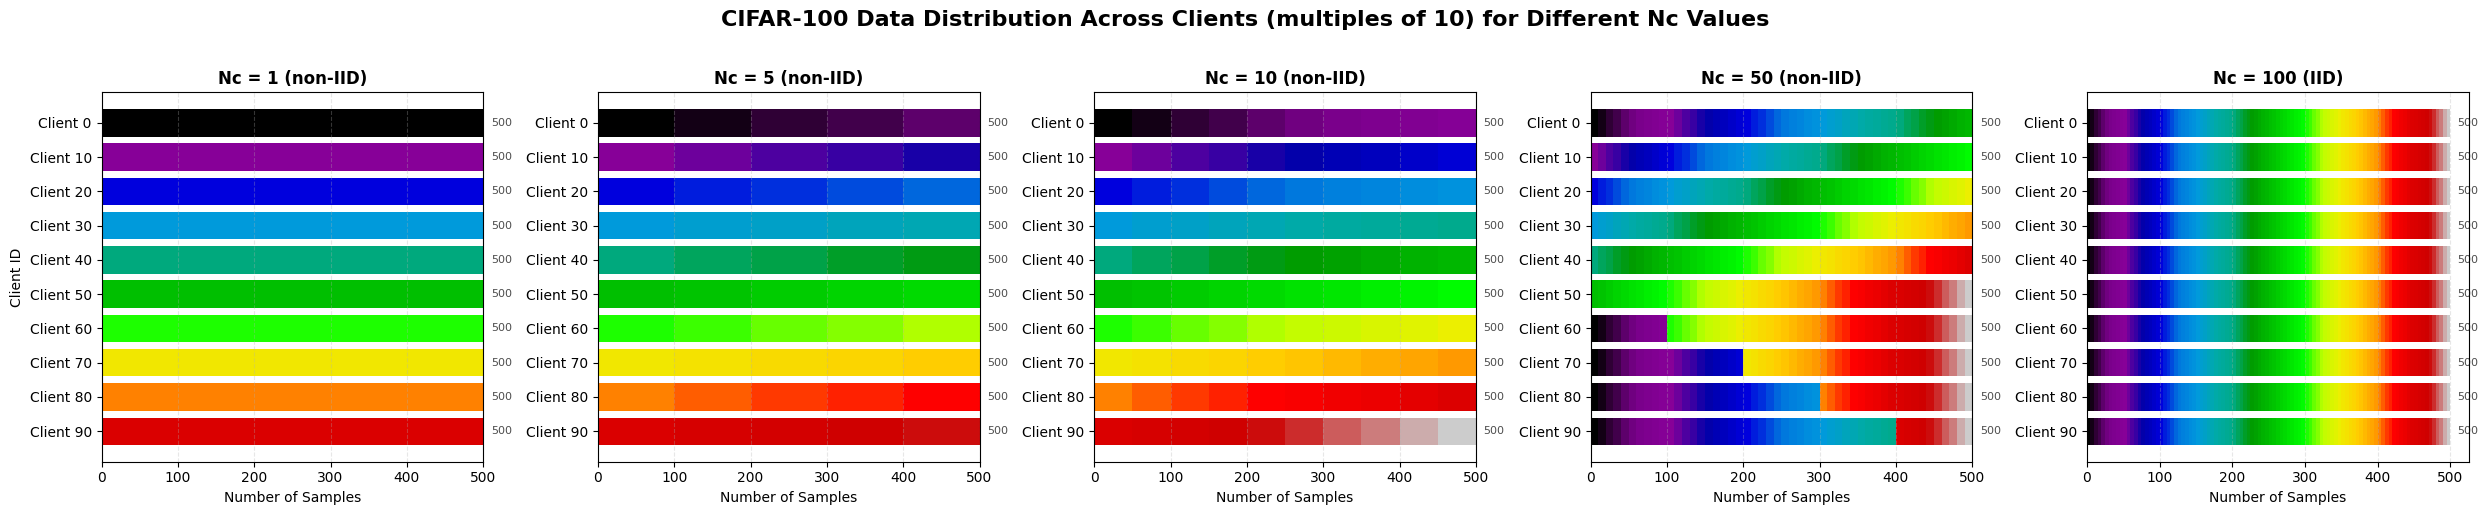

In [1]:
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import PathologicalPartitioner
import matplotlib.pyplot as plt
import numpy as np

# Imposta dimensione in pixel e dpi
width_px = 2500
height_px = 500
dpi = 100

# Configuration: 100 total partitions on fine_label (100 CIFAR-100 classes)
num_total_partitions = 100
# Select clients that are multiples of 10: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
clients_to_show = [i for i in range(num_total_partitions - 10, -1, -10)]
num_clients_to_show = len(clients_to_show)
seed = 54  # Same seed as in task.py

# Different Nc values (number of classes per partition)
nc_values = [1, 5, 10, 50, 100]

# Create figure with 5 subplots (one per Nc value)
fig, axes = plt.subplots(1, 5, figsize=(width_px / dpi, height_px / dpi), dpi=dpi)
fig.suptitle(
    "CIFAR-100 Data Distribution Across Clients (multiples of 10) for Different Nc Values",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

for idx, nc in enumerate(nc_values):
    # Create partitioner with specific Nc
    partitioner = PathologicalPartitioner(
        num_partitions=num_total_partitions,
        partition_by="fine_label",  # 100 classes
        num_classes_per_partition=nc,
        class_assignment_mode="deterministic",
        shuffle=True,
        seed=seed,
    )

    # Create FederatedDataset
    fds = FederatedDataset(
        dataset="uoft-cs/cifar100",
        partitioners={"train": partitioner},
    )

    # Manually create the distribution plot for selected clients
    ax = axes[idx]

    # Collect data for each selected client
    data_matrix = []
    for client_id in clients_to_show:
        partition = fds.load_partition(client_id)
        labels = [sample["fine_label"] for sample in partition]
        # Count occurrences of each class
        class_counts = np.bincount(labels, minlength=100)
        data_matrix.append(class_counts)

    data_matrix = np.array(data_matrix)

    # Create stacked bar chart with 100 distinct colors
    # Use nipy_spectral colormap which provides good color variety
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, 100))

    left = np.zeros(num_clients_to_show)
    for class_id in range(100):
        counts = data_matrix[:, class_id]
        if counts.sum() > 0:  # Only plot if there are samples
            ax.barh(
                range(num_clients_to_show),
                counts,
                left=left,
                color=colors[class_id],
                edgecolor="none",
                height=0.8,
            )
            left += counts

    # Customize subplot
    ax.set_title(
        f"Nc = {nc} {'(IID)' if nc == 100 else '(non-IID)'}",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Number of Samples", fontsize=10)
    ax.set_yticks(range(num_clients_to_show))
    ax.set_yticklabels([f"Client {i}" for i in clients_to_show])
    ax.grid(axis="x", alpha=0.3, linestyle="--")

    if idx == 0:
        ax.set_ylabel("Client ID", fontsize=10)

    # Add text with total samples per client
    for i in range(num_clients_to_show):
        total = data_matrix[i].sum()
        ax.text(total + 10, i, f"{int(total)}", va="center", fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig(
    "../report/images/cifar100_partitioning_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

---

## Part 2: WandB Multi-Run Experiment Results

Extract and visualize metrics from multiple Weights & Biases runs to compare different federated learning configurations.

In [2]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Configuration
ENTITY = "aml-fl-project"  # e.g. username or team
PROJECT = "fl-task-arithmetic"  # project name
METRIC = "accuracy"  # metric to plot
X_AXIS = "epoch"

In [4]:
api = wandb.Api()
runs = api.runs(f"{ENTITY}/{PROJECT}")
print(f"Found {len(runs)} runs")

Found 138 runs


In [5]:
# Stampa i nomi di tutte le run contenute in runs
for run in runs:
    print(run.name)

icarl-centroids
icarl-centroids
icarl-centroids-eval
icarl-centroids
icarl-centroids-eval
icarl-centroids
icarl-centroids
icarl-centroids-eval
adrien-9-centralized-dino-icarl-cifar100-lr0.0001-mom0.9-wd0.0005-sched-CosineAnnealingLR
adrien-10-centralized-dino-icarl-cifar100-lr1e-05-mom0.9-wd0.0005-sched-CosineAnnealingLR
adrien-12-T=30-centralized-dino-icarl-cifar100-lr0.001-mom0.9-wd0.0005-sched-CosineAnnealingLR
centralized-dino-icarl-cifar100-lr0.0001-mom0.9-wd0.0005
centralized-dino-icarl-cifar100-lr1e-05-mom0.9-wd0.0005-CosineAnnealing
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
server
serve

### Centralized Baseline

✓ Run trovata: centralized-baseline-lr0.0001-mom0.9-wd0.0005-schedcosine - 13 record
✓ Run trovata: centralized-baseline-lr0.0001-mom0.9-wd0.0005-schednone - 14 record
✓ Run trovata: centralized-baseline-lr0.0001-mom0.9-wd0.0005-schedcosinet5 - 11 record
✓ Run trovata: centralized-baseline-lr1e-05-mom0.9-wd0.0005-schednone - 16 record


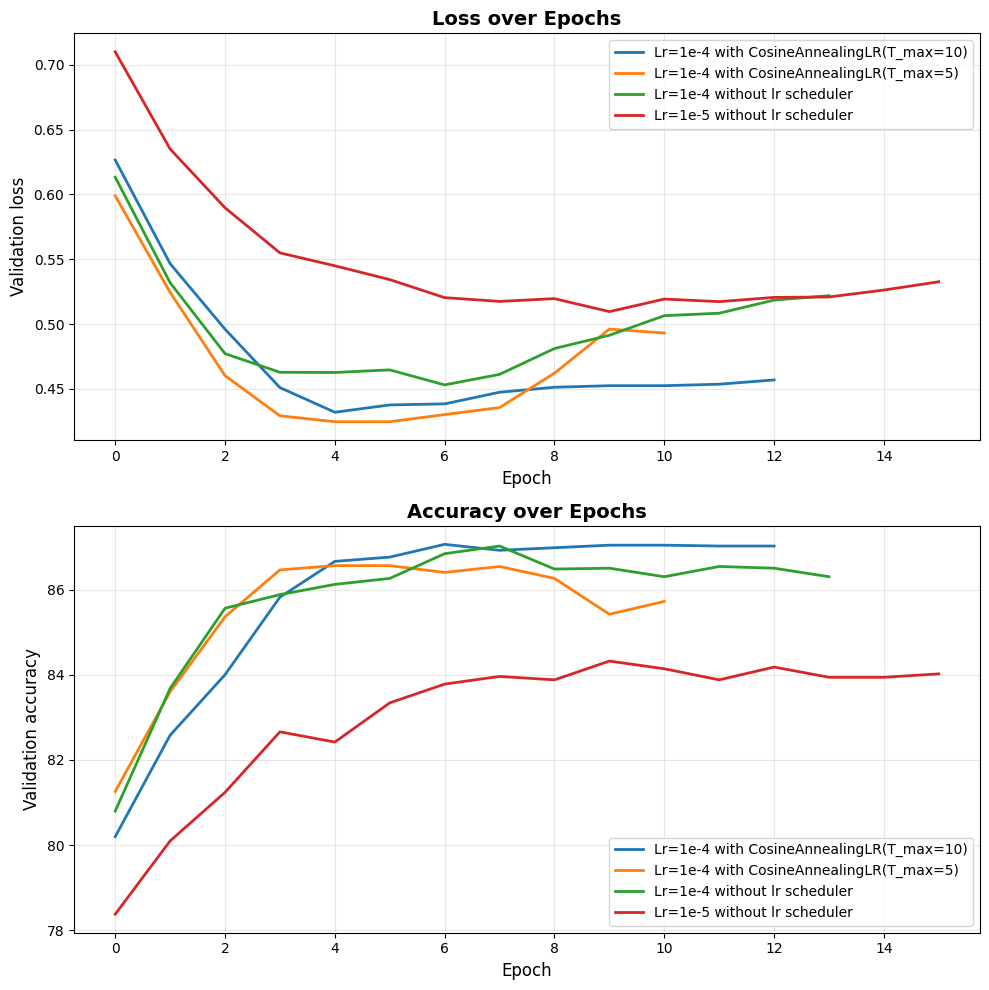

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Configura qui le tue run specifiche con le label custom
run_config = {
    "centralized-baseline-lr0.0001-mom0.9-wd0.0005-schedcosine": "Lr=1e-4 with CosineAnnealingLR(T_max=10)",
    "centralized-baseline-lr0.0001-mom0.9-wd0.0005-schedcosinet5": "Lr=1e-4 with CosineAnnealingLR(T_max=5)",
    "centralized-baseline-lr0.0001-mom0.9-wd0.0005-schednone": "Lr=1e-4 without lr scheduler",
    "centralized-baseline-lr1e-05-mom0.9-wd0.0005-schednone": "Lr=1e-5 without lr scheduler",
}

# Filtra le run dall'oggetto runs e raccogli i dati
run_data_dict = {}
for run in runs:
    if run.name in run_config:
        try:
            # Ottieni la history con loss e accuracy
            hist = run.history(keys=["val_loss", "val_accuracy"], pandas=True)
            hist = hist.dropna(subset=["val_loss", "val_accuracy"])
            hist["epoch"] = range(len(hist))
            run_data_dict[run.name] = hist
            print(f"✓ Run trovata: {run.name} - {len(hist)} record")
        except Exception as e:
            print(f"✗ Errore nel caricare {run.name}: {e}")

# Crea figura con due subplot (loss e accuracy)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Grafico 1: Loss
ax1 = axes[0]
for run_name, label in run_config.items():
    if run_name in run_data_dict:
        data = run_data_dict[run_name]
        ax1.plot(data["epoch"], data["val_loss"], label=label, linewidth=2)

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Validation loss", fontsize=12)
ax1.set_title("Loss over Epochs", fontsize=14, fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Grafico 2: Accuracy
ax2 = axes[1]
for run_name, label in run_config.items():
    if run_name in run_data_dict:
        data = run_data_dict[run_name]
        ax2.plot(data["epoch"], data["val_accuracy"], label=label, linewidth=2)

ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Validation accuracy", fontsize=12)
ax2.set_title("Accuracy over Epochs", fontsize=14, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../report/images/centralized_baseline_loss_acc.png", dpi=300, bbox_inches="tight"
)
plt.show()

### FL-Baselines

In [6]:
records = []

for run in runs:
    try:
        hist = run.history(keys=[METRIC], pandas=True)
        hist = hist.dropna(subset=[METRIC])
        hist["run_name"] = run.group
        records.append(hist[[METRIC, "run_name"]])
    except Exception as e:
        # print(f"Skipping {run.name}: {e}")
        continue

df = pd.concat(records)
df[X_AXIS] = df.groupby("run_name").cumcount()

# 1. Define which runs need trimming and how many initial epochs to skip
# Format: "run_name_from_wandb_group": number_of_epochs_to_skip
skip_epochs_config = {
    "baseline-fedavg-nc1-j4": 3,
    "baseline-fedavg-nc10-j4": 1,
    "baseline-fedavg-nc100-j8": 6,
    "baseline-fedavg-nc50-j8": 1,
    "baseline-fedavg-nc10-j8": 1,
    "baseline-fedavg-nc50-j16": 1,
    "baseline-fedavg-nc5-j16": 1,
}

# 2. Filter the DataFrame
for run_name, skip_count in skip_epochs_config.items():
    df = df[~((df["run_name"] == run_name) & (df["epoch"] < skip_count))]

df[X_AXIS] = df.groupby("run_name").cumcount() + 1

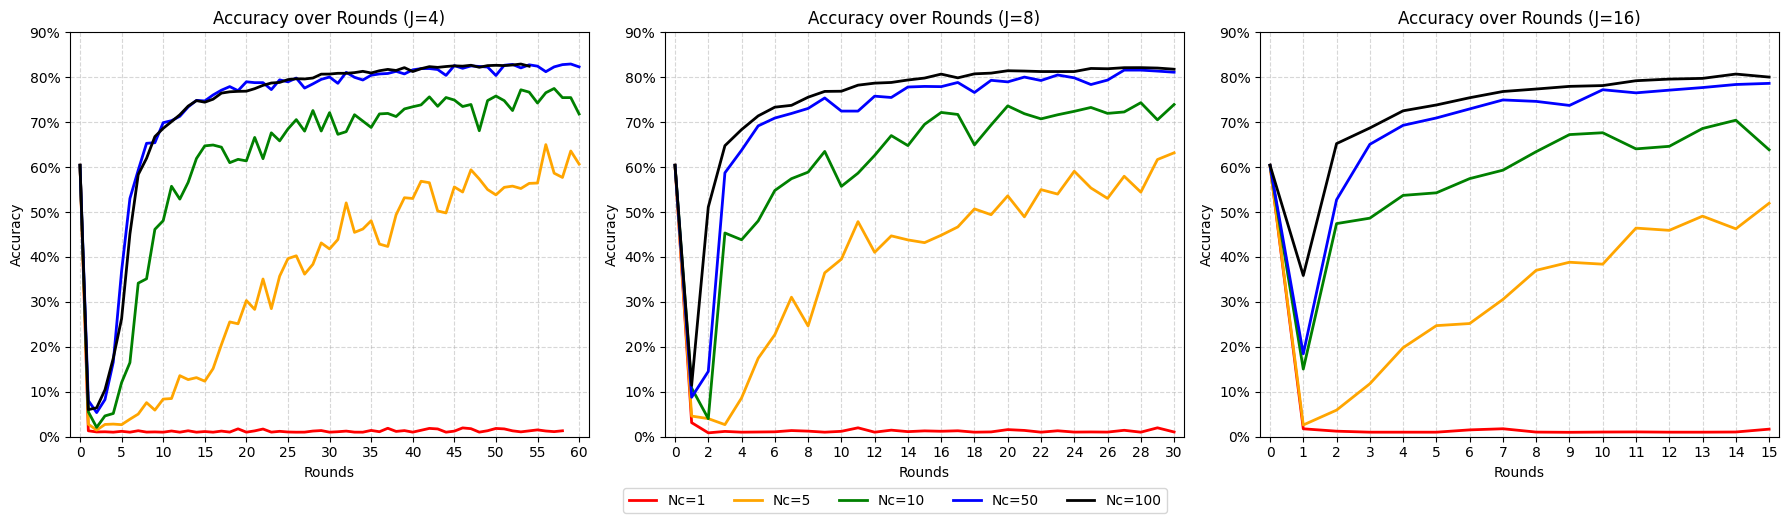

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Configuration
METRIC = "accuracy"
X_AXIS = "epoch"

# Set up consistent colors per Nc
colors = {1: "red", 5: "orange", 10: "green", 50: "blue", 100: "black"}

J_values = [4, 8, 16]
Nc_values = [1, 5, 10, 50, 100]

# Imposta dimensione in pixel e dpi
width_px = 1800
height_px = 500
dpi = 100

# Epoche massime e passo delle xtick per ogni J
max_epochs = {4: 60, 8: 30, 16: 15}
tick_steps = {4: 5, 8: 2, 16: 1}

# Padding percentuale per l'asse X
x_padding = 0.02  # 5% di padding su ogni lato

# Crea 1 riga, 3 colonne
fig, axes = plt.subplots(1, len(J_values), dpi=dpi)
fig.set_size_inches(width_px / dpi, height_px / dpi)

for idx, J in enumerate(J_values):
    ax = axes[idx]
    ax.set_title(f"Accuracy over Rounds (J={J})")

    for Nc in Nc_values:
        group_name = f"baseline-fedavg-nc{Nc}-j{J}"
        g = df[df["run_name"] == group_name]
        if g.empty:
            print(f"No data for {group_name}")
            continue
        g = g.sort_values(X_AXIS)
        # Assicura un punto iniziale a epoch 0 con valore fissato
        if not g.empty:
            # Se esiste già epoch 0, forza il valore; altrimenti aggiungi la riga
            if (g[X_AXIS] == 0).any():
                g.loc[g[X_AXIS] == 0, METRIC] = 0.6041
            else:
                start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": group_name}
                g = pd.concat([pd.DataFrame([start_row]), g], ignore_index=True)
        # Tronca alle epoche desiderate
        g = g[g[X_AXIS] <= max_epochs[J]]
        ax.plot(g[X_AXIS], g[METRIC], label=f"Nc={Nc}", color=colors[Nc], linewidth=2)
    # Aggiungi padding proporzionale
    padding = max_epochs[J] * x_padding
    ax.set_xlim(-padding, max_epochs[J] + padding)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylim(0, 0.9)
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(range(0, max_epochs[J] + 1, tick_steps[J]))
    ax.grid(True, linestyle="--", alpha=0.5)
    # Mostra la leggenda una sola volta sotto tutta la figura
    if idx == len(J_values) - 1:
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=len(Nc_values),
            bbox_to_anchor=(0.5, -0.05),
        )

plt.tight_layout()
plt.savefig("../report/images/baseline_accuracy_by_j.png", dpi=300, bbox_inches="tight")
plt.show()

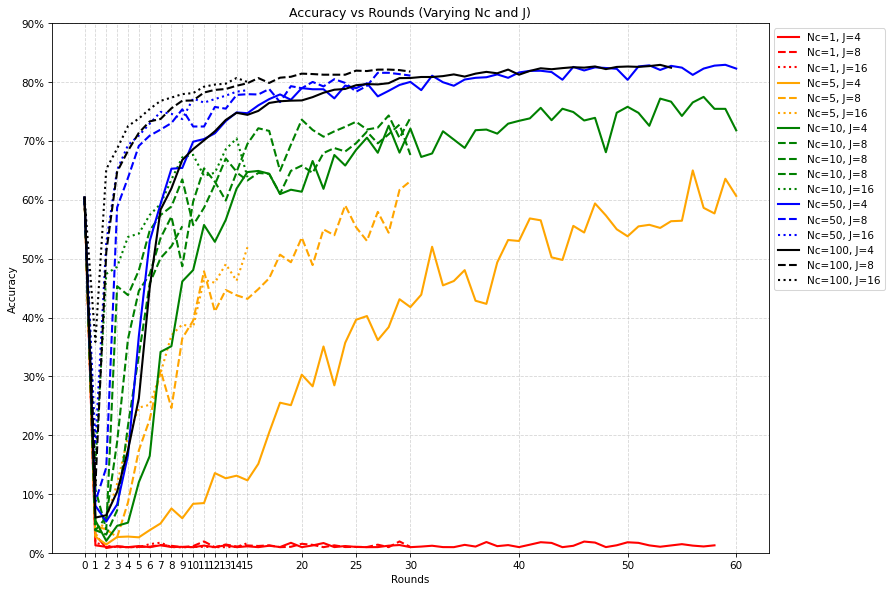

In [8]:
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Configuration
METRIC = "accuracy"
X_AXIS = "epoch"

# Dimensioni e dpi figura
width_px = 900
height_px = 600
dpi = 75

# Padding percentuale per l'asse X
x_padding = 0.05  # 5% di padding su ogni lato

# Define style mappings
colors = {1: "red", 5: "orange", 10: "green", 50: "blue", 100: "black"}
line_styles = {4: "-", 8: "--", 16: ":"}  # solid  # dashed  # dotted

# Troncamenti e passi xtick per J
max_epochs = {4: 60, 8: 30, 16: 15}
tick_steps = {4: 10, 8: 5, 16: 1}


# Function to extract Nc and J from the run group name
def parse_run_params(run_name):
    # Matches patterns like "...-nc100-j16..."
    match = re.search(r"nc(\d+)-j(\d+)", run_name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None


fig, ax = plt.subplots(figsize=(width_px / dpi, height_px / dpi), dpi=dpi)

# Identify all unique runs in the dataframe
run_names = df["run_name"].unique()

# Filter and sort runs to ensure the legend is logical
valid_runs = []
for r in run_names:
    nc, j = parse_run_params(r)
    # Only include if we found the params and they match our style keys
    if nc in colors and j in line_styles:
        valid_runs.append((nc, j, r))

# Sort by Nc, then by J
valid_runs.sort(key=lambda x: (x[0], x[1]))

# Precompute combined xticks to respect different J spacings
xticks = set()
for j, step in tick_steps.items():
    xticks.update(range(0, max_epochs[j] + 1, step))
xticks = sorted(xticks)

# Plot each run
for nc, j, r_name in valid_runs:
    subset = df[df["run_name"] == r_name].sort_values(X_AXIS)
    if subset.empty:
        continue
    # Assicura un punto iniziale a epoch 0 con valore fissato
    if (subset[X_AXIS] == 0).any():
        subset.loc[subset[X_AXIS] == 0, METRIC] = 0.6041
    else:
        start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": r_name}
        subset = pd.concat([pd.DataFrame([start_row]), subset], ignore_index=True)
    # Tronca in base al valore di J
    if j in max_epochs:
        subset = subset[subset[X_AXIS] <= max_epochs[j]]
    ax.plot(
        subset[X_AXIS],
        subset[METRIC],
        label=f"Nc={nc}, J={j}",
        color=colors[nc],
        linestyle=line_styles[j],
        linewidth=2,
    )

ax.set_title("Accuracy vs Rounds (Varying Nc and J)")
# Aggiungi padding proporzionale
max_x = max(max_epochs.values())
padding = max_x * x_padding
ax.set_xlim(-padding, max_x + padding)
ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Rounds")
ax.set_ylabel("Accuracy")
ax.set_xticks(xticks)
ax.grid(True, linestyle="--", alpha=0.5)

ax.legend(bbox_to_anchor=(1.00, 1), loc="best")  # Move legend outside if crowded
plt.tight_layout()
plt.savefig(
    "../report/images/baseline_accuracy_varying_nc_j.png", dpi=300, bbox_inches="tight"
)
plt.show()

### Task arithmetic

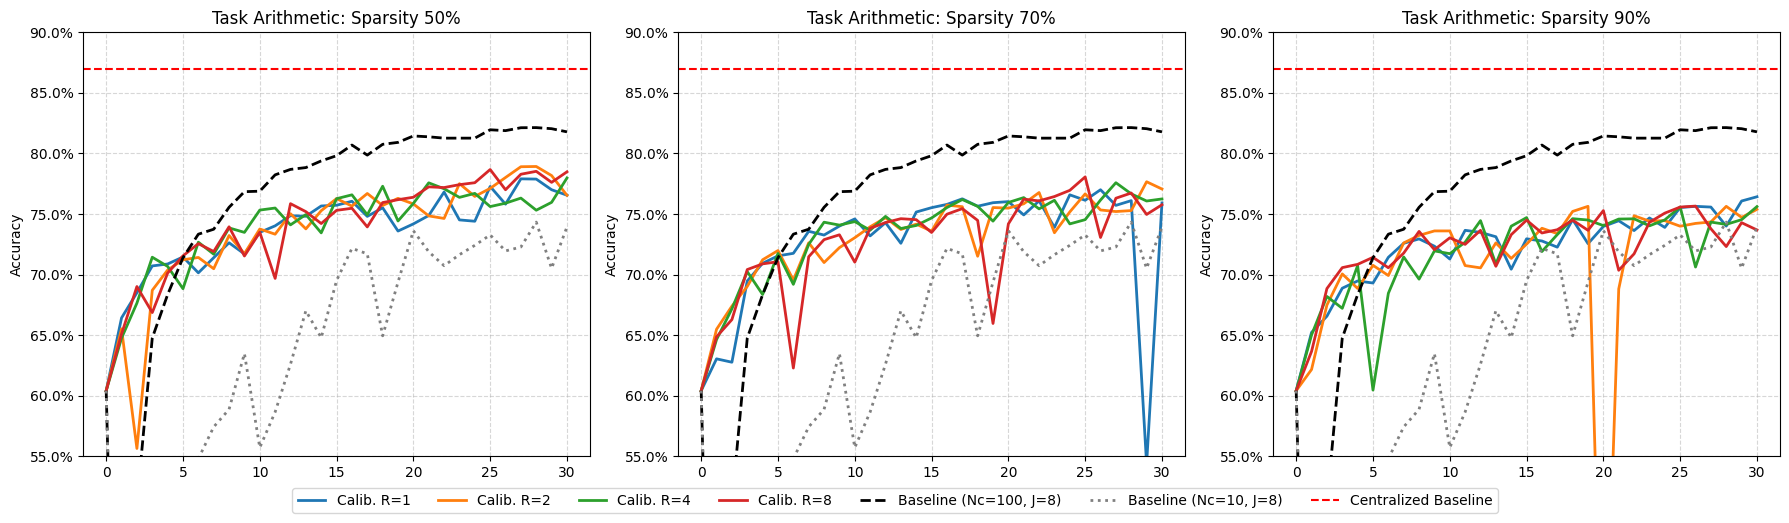

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Configuration
METRIC = "accuracy"
X_AXIS = "epoch"
CENTRALIZED_ACC = 0.8697

# 1. Define Group Names Mapping based on config files
# Structure: {sparsity: {rounds: 'wandb_group_name'}}
# Note: Inconsistencies in naming (e.g., 'V2-' prefix) are handled here.
ta_groups = {
    50: {
        1: "V2-task-arithmetic-s50-r1-V2",
        2: "V2-task-arithmetic-s50-r2-V2",
        4: "task-arithmetic-s50-r4-V2",
        8: "task-arithmetic-s50-r8-V2",
    },
    70: {
        1: "task-arithmetic-s70-r1-V2",
        2: "task-arithmetic-s70-r2",
        4: "task-arithmetic-s70-r4-V2",
        8: "task-arithmetic-s70-r8-V2",
    },
    90: {
        1: "task-arithmetic-s90-r1-V2",
        2: "task-arithmetic-s90-r2-V2",
        4: "task-arithmetic-s90-r4-V2",
        8: "task-arithmetic-s90-r8-V2",
    },
}

baseline_nc100 = "baseline-fedavg-nc100-j8"
baseline_nc10 = "baseline-fedavg-nc10-j8"

# Imposta dimensione in pixel e dpi
width_px = 1800
height_px = 500
dpi = 100

# Padding percentuale per l'asse X
x_padding = 0.05  # 5% di padding su ogni lato
max_rounds = 30

sparsities = [50, 70, 90]

# Crea 1 riga, 3 colonne
fig, axes = plt.subplots(1, len(sparsities), dpi=dpi)
fig.set_size_inches(width_px / dpi, height_px / dpi)

for idx, s in enumerate(sparsities):
    ax = axes[idx]
    ax.set_title(f"Task Arithmetic: Sparsity {s}%")

    # Plot Task Arithmetic runs
    for r, group_name in ta_groups[s].items():
        subset = df[df["run_name"] == group_name].sort_values(X_AXIS)
        if not subset.empty:
            # Assicura un punto iniziale a round 0 con valore fissato
            if (subset[X_AXIS] == 0).any():
                subset.loc[subset[X_AXIS] == 0, METRIC] = 0.6041
            else:
                start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": group_name}
                subset = pd.concat(
                    [pd.DataFrame([start_row]), subset], ignore_index=True
                )
            # Tronca a round 30
            subset = subset[subset[X_AXIS] <= 30]
            ax.plot(subset[X_AXIS], subset[METRIC], label=f"Calib. R={r}", linewidth=2)

    # Plot Baselines
    base100 = df[df["run_name"] == baseline_nc100].sort_values(X_AXIS)
    if not base100.empty:
        # Assicura punto iniziale baseline
        if (base100[X_AXIS] == 0).any():
            base100.loc[base100[X_AXIS] == 0, METRIC] = 0.6041
        else:
            start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": baseline_nc100}
            base100 = pd.concat([pd.DataFrame([start_row]), base100], ignore_index=True)
        # Tronca a round 30
        base100 = base100[base100[X_AXIS] <= 30]
        ax.plot(
            base100[X_AXIS],
            base100[METRIC],
            label="Baseline (Nc=100, J=8)",
            color="black",
            linestyle="--",
            linewidth=2,
        )

    base10 = df[df["run_name"] == baseline_nc10].sort_values(X_AXIS)
    if not base10.empty:
        # Assicura punto iniziale baseline
        if (base10[X_AXIS] == 0).any():
            base10.loc[base10[X_AXIS] == 0, METRIC] = 0.6041
        else:
            start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": baseline_nc10}
            base10 = pd.concat([pd.DataFrame([start_row]), base10], ignore_index=True)
        # Tronca a round 30
        base10 = base10[base10[X_AXIS] <= 30]
        ax.plot(
            base10[X_AXIS],
            base10[METRIC],
            label="Baseline (Nc=10, J=8)",
            color="grey",
            linestyle=":",
            linewidth=2,
        )

    ax.axhline(
        y=CENTRALIZED_ACC, color="red", linestyle="--", label="Centralized Baseline"
    )
    # Aggiungi padding proporzionale
    padding = max_rounds * x_padding
    ax.set_xlim(-padding, max_rounds + padding)
    ax.set_ylim(0.55, 0.9)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylabel("Accuracy")
    ax.grid(True, linestyle="--", alpha=0.5)

    # Mostra la leggenda una sola volta sotto tutta la figura
    if idx == len(sparsities) - 1:
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=7,
            bbox_to_anchor=(0.5, -0.05),
        )


plt.tight_layout()
plt.savefig(
    "../report/images/task_arithmetic_sparsity.png", dpi=300, bbox_inches="tight"
)
plt.show()

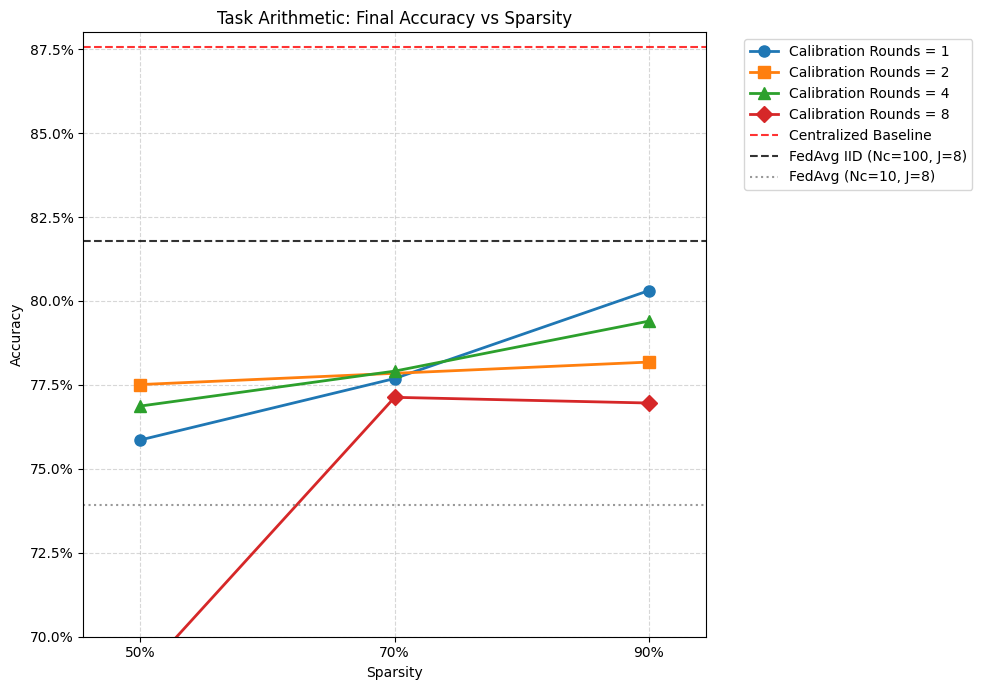

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# Configuration
METRIC = "accuracy"
X_AXIS = "epoch"
CENTRALIZED_ACC = 0.8697
AVG_WINDOW = 0  # media sui round [30-AVG_WINDOW, 30]

# 1. Define Run Mapping (Sparsity -> Rounds -> Group Name)
ta_groups_config = {
    50: {
        1: "task-arithmetic-s50-r1-FIX-MASK",
        2: "task-arithmetic-s50-r2-FIX-MASK",
        4: "task-arithmetic-s50-r4-FIX-MASK",
        8: "task-arithmetic-s50-r8-FIX-MASK",
    },
    70: {
        1: "task-arithmetic-s70-r1-FIX-MASK",
        2: "task-arithmetic-s70-r2-FIX-MASK",
        4: "task-arithmetic-s70-r4-FIX-MASK",
        8: "task-arithmetic-s70-r8-FIX-MASK",
    },
    90: {
        1: "task-arithmetic-s90-r1-FIX-MASK",
        2: "task-arithmetic-s90-r2-FIX-MASK",
        4: "task-arithmetic-s90-r4-FIX-MASK",
        8: "task-arithmetic-s90-r8-FIX-MASK",
    },
}

baselines = {
    "FedAvg IID (Nc=100, J=8)": "baseline-fedavg-nc100-j8",
    "FedAvg (Nc=10, J=8)": "baseline-fedavg-nc10-j8",
}

CENTRALIZED_ACC = 0.8755  # Fixed value

# 2. Extract average accuracy on [30-AVG_WINDOW, 30]
data = []

# Process Task Arithmetic runs
for sparsity, rounds_dict in ta_groups_config.items():
    for r, run_name in rounds_dict.items():
        # Get average accuracy on [30-AVG_WINDOW, 30] for this run
        run_data = df[
            (df["run_name"] == run_name)
            & (df[X_AXIS] >= 30 - AVG_WINDOW)
            & (df[X_AXIS] <= 30)
        ][METRIC]
        if not run_data.empty:
            max_acc = run_data.mean()
            data.append(
                {
                    "Sparsity": sparsity,
                    "Rounds": r,
                    "Accuracy": max_acc,
                    "Type": "Task Arithmetic",
                }
            )

# Process Baselines
baseline_vals = {}
for label, run_name in baselines.items():
    run_data = df[
        (df["run_name"] == run_name)
        & (df[X_AXIS] >= 30 - AVG_WINDOW)
        & (df[X_AXIS] <= 30)
    ][METRIC]
    if not run_data.empty:
        baseline_vals[label] = run_data.mean()
    else:
        baseline_vals[label] = None

# Create DataFrame for easier plotting
res_df = pd.DataFrame(data)

# 3. Plotting
# Imposta dimensione in pixel e dpi
width_px = 1000
height_px = 700
dpi = 100

# Padding percentuale per l'asse X
x_padding = 0.05  # 5% di padding su ogni lato
max_sparsity = 90

fig = plt.figure(figsize=(width_px / dpi, height_px / dpi), dpi=dpi)

# Plot lines for each Calibration Round count
rounds_options = sorted(res_df["Rounds"].unique())
markers = ["o", "s", "^", "D"]  # distinct markers for rounds

for i, r in enumerate(rounds_options):
    subset = res_df[res_df["Rounds"] == r].sort_values("Sparsity")
    plt.plot(
        subset["Sparsity"],
        subset["Accuracy"],
        marker=markers[i],
        linewidth=2,
        markersize=8,
        label=f"Calibration Rounds = {r}",
    )

# Plot Horizontal Baselines
colors = ["black", "grey"]
styles = ["--", ":"]

# Centralized
plt.axhline(
    y=CENTRALIZED_ACC,
    color="red",
    linestyle="--",
    label="Centralized Baseline",
    alpha=0.8,
)

# FedAvg Baselines
for i, (label, val) in enumerate(baseline_vals.items()):
    if val is not None:
        plt.axhline(
            y=val,
            color=colors[i],
            linestyle=styles[i],
            label=f"{label}",
            alpha=0.8,
        )

# Styling
plt.title("Task Arithmetic: Final Accuracy vs Sparsity")
plt.ylabel("Accuracy")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
min_sparsity = min(sparsities)
max_sparsity_tick = max(sparsities)
padding = max_sparsity_tick * x_padding
plt.xlim(min_sparsity - padding, max_sparsity_tick + padding)

plt.xticks(sparsities, [f"{s}%" for s in sparsities])
plt.xlabel("Sparsity")

plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(0.65, 0.88)

# Legend
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(
    "../report/images/task_arithmetic_final_accuracy_vs_sparsity.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Extension

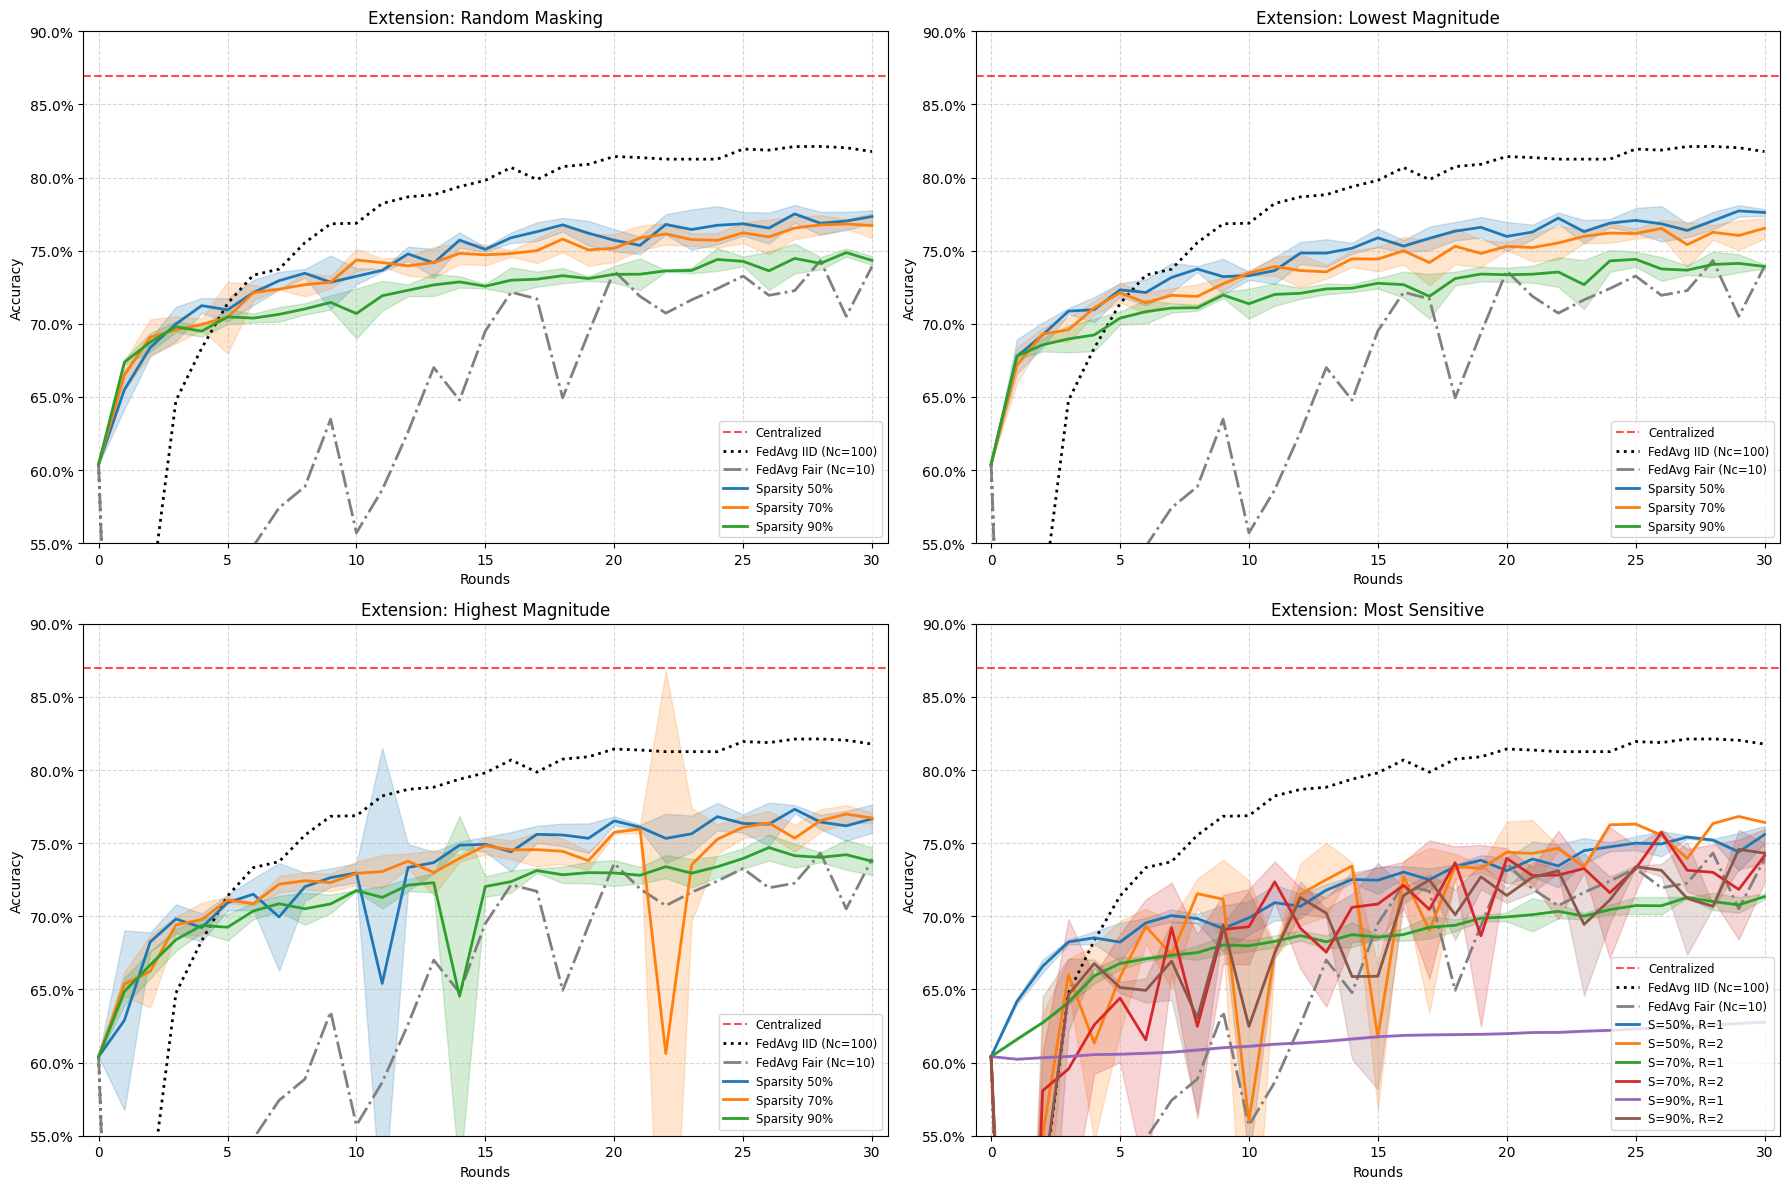

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import re
import numpy as np
from matplotlib.ticker import PercentFormatter

# --- Configuration & Constants ---
CENTRALIZED_ACC = 0.8697
METRIC = "accuracy"
X_AXIS = "epoch"

# Imposta dimensione in pixel e dpi
width_px = 1800
height_px = 1200
dpi = 100

# Padding percentuale per l'asse X
x_padding = 0.02
max_rounds = 30

# Define Baseline Groups
BASELINE_IID = "baseline-fedavg-nc100-j8"
BASELINE_FAIR = "baseline-fedavg-nc10-j8"
BEST_TA_GROUP = "task_arithmetic_s70_r8-V2"


# Helper function to normalize run names (remove -RUNx suffix)
def get_base_name(run_name):
    # Regex to remove -RUN1, -RUN2, etc. at the end
    return re.sub(r"-RUN\d+$", "", run_name)


# Create a 'base_name' column for aggregation
df["base_name"] = df["run_name"].apply(get_base_name)

# Pre-calculate aggregated data (mean & std) for all base_names
# Group by base_name and epoch
agg_df = df.groupby(["base_name", X_AXIS])[METRIC].agg(["mean", "std"]).reset_index()


# Function to plot a single extension chart
def plot_extension(extension_name, config_dict, ax, ylim=(0.6, 0.85)):
    # 1. Plot Baselines (Fixed for all charts)

    # Centralized
    ax.axhline(
        y=CENTRALIZED_ACC, color="red", linestyle="--", label="Centralized", alpha=0.7
    )

    # FedAvg IID
    iid_data = df[df["run_name"] == BASELINE_IID].sort_values(X_AXIS)
    if not iid_data.empty:
        # Assicura punto iniziale baseline
        if (iid_data[X_AXIS] == 0).any():
            iid_data.loc[iid_data[X_AXIS] == 0, METRIC] = 0.6041
        else:
            start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": BASELINE_IID}
            iid_data = pd.concat(
                [pd.DataFrame([start_row]), iid_data], ignore_index=True
            )
        # Tronca a round 30
        iid_data = iid_data[iid_data[X_AXIS] <= 30]
        ax.plot(
            iid_data[X_AXIS],
            iid_data[METRIC],
            color="black",
            linestyle=":",
            label="FedAvg IID (Nc=100)",
            linewidth=2,
        )

    # FedAvg Fair
    fair_data = df[df["run_name"] == BASELINE_FAIR].sort_values(X_AXIS)
    if not fair_data.empty:
        # Assicura punto iniziale baseline
        if (fair_data[X_AXIS] == 0).any():
            fair_data.loc[fair_data[X_AXIS] == 0, METRIC] = 0.6041
        else:
            start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": BASELINE_FAIR}
            fair_data = pd.concat(
                [pd.DataFrame([start_row]), fair_data], ignore_index=True
            )
        # Tronca a round 30
        fair_data = fair_data[fair_data[X_AXIS] <= 30]
        ax.plot(
            fair_data[X_AXIS],
            fair_data[METRIC],
            color="grey",
            linestyle="-.",
            label="FedAvg Fair (Nc=10)",
            linewidth=2,
        )

    # Best Task Arithmetic
    # Check if we need to aggregate or if it's a single run
    ta_base = get_base_name(BEST_TA_GROUP)
    ta_data = agg_df[agg_df["base_name"] == ta_base].sort_values(X_AXIS)
    if not ta_data.empty:
        # Tronca a round 30
        ta_data = ta_data[ta_data[X_AXIS] <= 30]
        ax.plot(
            ta_data[X_AXIS],
            ta_data["mean"],
            color="purple",
            linestyle="-",
            label="Best Task Arithmetic",
            linewidth=2,
        )

    # 2. Plot Extension Curves
    # Iterate through the specific configs for this extension
    for label, base_group in config_dict.items():
        subset = agg_df[agg_df["base_name"] == base_group].sort_values(X_AXIS)

        if not subset.empty:
            # Assicura punto iniziale a round 0 con valore fissato
            if (subset[X_AXIS] == 0).any():
                subset.loc[subset[X_AXIS] == 0, "mean"] = 0.6041
            else:
                start_row = {X_AXIS: 0, "mean": 0.6041, "std": 0}
                subset = pd.concat(
                    [pd.DataFrame([start_row]), subset], ignore_index=True
                )
            # Tronca a round 30
            subset = subset[subset[X_AXIS] <= 30]
            # Plot Mean Line
            (line,) = ax.plot(subset[X_AXIS], subset["mean"], label=label, linewidth=2)

            # Fill Standard Deviation
            ax.fill_between(
                subset[X_AXIS],
                subset["mean"] - subset["std"].fillna(0),
                subset["mean"] + subset["std"].fillna(0),
                color=line.get_color(),
                alpha=0.2,
            )

    # Formatting
    ax.set_title(f"Extension: {extension_name}")
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Accuracy")
    # Aggiungi padding proporzionale
    padding = max_rounds * x_padding
    ax.set_xlim(-padding, max_rounds + padding)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_ylim(ylim)
    ax.legend(fontsize="small", loc="lower right")


# --- Define Extension Configurations ---

# 1. Random Masking (Sparsity 50, 70, 90)
random_configs = {
    "Sparsity 50%": "random-masking-s50",
    "Sparsity 70%": "random-masking-s70",
    "Sparsity 90%": "random-masking-s90",
}

# 2. Lowest Magnitude (Sparsity 50, 70, 90)
low_mag_configs = {
    "Sparsity 50%": "lowest-magnitude-s50",
    "Sparsity 70%": "lowest-magnitude-s70",
    "Sparsity 90%": "lowest-magnitude-s90",
}

# 3. Highest Magnitude (Sparsity 50, 70, 90)
high_mag_configs = {
    "Sparsity 50%": "highest-magnitude-s50",
    "Sparsity 70%": "highest-magnitude-s70",
    "Sparsity 90%": "highest-magnitude-s90",
}

# 4. Most Sensitive (Sparsity 50/70/90 x Rounds 1/2)
# Note: Base names derived from config patterns (e.g., most-sensitive-s50-r1)
most_sens_configs = {
    "S=50%, R=1": "most-sensitive-s50-r1",
    "S=50%, R=2": "most-sensitive-s50-r2-FIX-MASK",
    "S=70%, R=1": "most-sensitive-s70-r1",
    "S=70%, R=2": "most-sensitive-s70-r2-FIX-MASK",
    "S=90%, R=1": "most-sensitive-s90-r1",
    "S=90%, R=2": "most-sensitive-s90-r2-FIX-MASK",
}

# --- Generate Plots ---
fig, axes = plt.subplots(2, 2, figsize=(width_px / dpi, height_px / dpi), dpi=dpi)

plot_extension("Random Masking", random_configs, axes[0, 0], ylim=(0.55, 0.9))
plot_extension("Lowest Magnitude", low_mag_configs, axes[0, 1], ylim=(0.55, 0.9))
plot_extension("Highest Magnitude", high_mag_configs, axes[1, 0], ylim=(0.55, 0.9))
plot_extension("Most Sensitive", most_sens_configs, axes[1, 1], ylim=(0.55, 0.9))

plt.tight_layout()
plt.savefig("../report/images/extensions_comparison.png", dpi=300, bbox_inches="tight")
plt.show()